# Atelier Préparation de Données Images

**Contexte.** Une entreprise souhaite entraîner un modèle de Machine Learning / Deep Learning capable de reconnaître automatiquement le type de déchet présent sur une photographie (`cardboard`, `glass`, `metal`, `paper`, `plastic`, `trash`) afin d'améliorer le tri des déchets. Les images collectées proviennent de plusieurs sources et ne sont donc pas homogènes (dimensions, formats, modes couleur, qualité). L'objectif de cet atelier est de construire, à partir du dossier `data/raw/`, un jeu de données images propre et homogène (`data/cleaned/`), prêt à être utilisé pour l'entraînement.

## Imports et configuration

In [1]:
import os
import shutil
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

RAW_DIR = Path("../data/raw")
CLEANED_DIR = Path("../data/cleaned")
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(exist_ok=True)

CLASSES = sorted([d.name for d in RAW_DIR.iterdir() if d.is_dir()])
CLASSES

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

## Partie 1 – Exploration du dataset

### Fonction d'extraction des métadonnées d'une image

In [2]:
def extraire_metadonnees(chemin: Path, classe: str) -> dict:
    """Extrait nom, classe, format, mode, largeur, hauteur, ecart-type des pixels,
    nombre de canaux et taille (octets) d'une image. Robuste aux fichiers corrompus :
    les champs dependant du contenu de l'image restent a None si la lecture echoue."""
    infos = {
        'nom': chemin.name,
        'classe': classe,
        'chemin': str(chemin),
        'taille_octets': chemin.stat().st_size,
        'format': None,
        'mode': None,
        'largeur': None,
        'hauteur': None,
        'ecart_type_pixels': None,
        'canaux': None,
    }
    try:
        with Image.open(chemin) as img:
            img.load()  # force le decodage complet : declenche une erreur si le fichier est corrompu
            infos['format'] = img.format
            infos['mode'] = img.mode
            infos['largeur'], infos['hauteur'] = img.size
            infos['canaux'] = len(img.getbands())
            infos['ecart_type_pixels'] = float(np.array(img).std())
    except Exception:
        pass
    return infos

### Construction du DataFrame d'audit sur l'ensemble du dataset (`data/raw/`)

In [3]:
lignes = []
for classe in CLASSES:
    for chemin in sorted((RAW_DIR / classe).iterdir()):
        if chemin.is_file():
            lignes.append(extraire_metadonnees(chemin, classe))

df_audit = pd.DataFrame(lignes)
df_audit['resolution'] = list(zip(df_audit['largeur'], df_audit['hauteur']))
print(f"Nombre total d'images dans data/raw/ : {len(df_audit)}")
df_audit.shape

Nombre total d'images dans data/raw/ : 1032


(1032, 11)

### Aperçu du DataFrame d'audit

In [4]:
df_audit.head()

,nom,classe,chemin,taille_octets,format,mode,largeur,hauteur,ecart_type_pixels,canaux,resolution
0,cardboard1.jpg,cardboard,..\data\raw\cardboard\cardboard1.jpg,17333,JPEG,RGB,512.0,384.0,40.588529,3.0,"(512.0, 384.0)"
1,cardboard10.jpg,cardboard,..\data\raw\cardboard\cardboard10.jpg,21683,JPEG,RGB,512.0,384.0,42.571288,3.0,"(512.0, 384.0)"
2,cardboard100.jpg,cardboard,..\data\raw\cardboard\cardboard100.jpg,14884,JPEG,RGB,512.0,384.0,46.108305,3.0,"(512.0, 384.0)"
3,cardboard101.jpg,cardboard,..\data\raw\cardboard\cardboard101.jpg,14289,JPEG,RGB,512.0,384.0,72.263996,3.0,"(512.0, 384.0)"
4,cardboard102.jpg,cardboard,..\data\raw\cardboard\cardboard102.jpg,18015,JPEG,RGB,512.0,384.0,48.388937,3.0,"(512.0, 384.0)"


In [5]:
df_audit.dtypes

nom                      str
classe                   str
chemin                   str
taille_octets          int64
format                   str
mode                     str
largeur              float64
hauteur              float64
ecart_type_pixels    float64
canaux               float64
resolution            object
dtype: object

In [6]:
df_audit.describe(include='all')

,nom,classe,chemin,taille_octets,format,mode,largeur,hauteur,ecart_type_pixels,canaux,resolution
count,1032,1032,1032,1032.000000,1026,1026,1026.000000,1026.000000,1026.000000,1026.000000,1032
unique,1029,6,1032,NaN,3,3,NaN,NaN,NaN,NaN,5
top,image-blanche-512x384.jpg,paper,..\data\raw\cardboard\cardboard1.jpg,NaN,JPEG,RGB,NaN,NaN,NaN,NaN,"(512.0, 384.0)"
freq,2,252,1,NaN,1006,1006,NaN,NaN,NaN,NaN,1013
mean,NaN,NaN,NaN,18967.135659,NaN,NaN,506.011696,379.571150,50.251721,3.013645,NaN
std,NaN,NaN,NaN,17316.322788,NaN,NaN,52.892232,39.116528,15.982024,0.158680,NaN
min,NaN,NaN,NaN,924.000000,NaN,NaN,32.000000,32.000000,1.572536,1.000000,NaN
25%,NaN,NaN,NaN,11729.250000,NaN,NaN,512.000000,384.000000,38.694855,3.000000,NaN
50%,NaN,NaN,NaN,15488.000000,NaN,NaN,512.000000,384.000000,49.877604,3.000000,NaN
75%,NaN,NaN,NaN,20835.500000,NaN,NaN,512.000000,384.000000,61.796555,3.000000,NaN


### Répartition des formats et modes rencontrés

In [7]:
df_audit['format'].value_counts(dropna=False)

format
JPEG    1006
PNG       18
NaN        6
GIF        2
Name: count, dtype: int64

In [8]:
df_audit['mode'].value_counts(dropna=False)

mode
RGB     1006
RGBA      18
NaN        6
P          2
Name: count, dtype: int64

**Réponse.** Le dossier `data/raw/` contient **1032 images** réparties sur **6 classes** (cardboard, glass, metal, paper, plastic, trash). Les formats rencontrés sont **JPEG** (1006 images), **PNG** (18 images) et **GIF** (2 images) ; **6 fichiers** ne peuvent pas être décodés (`format` = `NaN`) : ce sont les images corrompues qui seront confirmées en Partie 2. Côté modes couleur, on trouve **1006 images en RGB**, **18 en RGBA** (canal alpha) et **2 en mode `P`** (palette indexée, typiques des GIF). Le dataset n'est donc pas homogène ni en format, ni en mode couleur, ni en dimensions (voir Partie 4).

## Suivi de l'audit (`reports/audit_images.csv`)

On accumule au fil de l'atelier les statistiques demandées par l'énoncé dans le dictionnaire `audit_stats`, sauvegardé dans `reports/audit_images.csv`.

In [9]:
audit_stats = {"total d'images": len(df_audit)}

def sauvegarder_audit():
    pd.DataFrame([audit_stats]).to_csv(REPORTS_DIR / 'audit_images.csv', index=False)
    return pd.DataFrame([audit_stats])

sauvegarder_audit()

,total d'images
0,1032


## Partie 2 – Détecter les images corrompues

### Fonction de détection d'une image corrompue

In [10]:
def est_corrompue(chemin: Path) -> bool:
    """Renvoie True si le fichier ne peut pas etre entierement decode comme une image (fichier tronque,
    en-tete invalide, etc.)."""
    try:
        with Image.open(chemin) as img:
            img.load()
        return False
    except Exception:
        return True

### Application de la fonction à l'ensemble du dataset

In [11]:
df_audit['corrompue'] = df_audit['chemin'].apply(lambda p: est_corrompue(Path(p)))
images_corrompues = df_audit[df_audit['corrompue']]
images_corrompues[['nom', 'classe']]

,nom,classe
147,cardboard83.jpg,cardboard
326,glass74.jpg,glass
446,metal48.jpg,metal
633,paper213.jpg,paper
791,plastic13.jpg,plastic
1004,trash3.jpg,trash


In [12]:
audit_stats["Images corrompues"] = len(images_corrompues)
sauvegarder_audit()

,total d'images,Images corrompues
0,1032,6


**Réponse.** La fonction `est_corrompue` détecte **6 images corrompues**, exactement une par classe (`cardboard83.jpg`, `glass74.jpg`, `metal48.jpg`, `paper213.jpg`, `plastic13.jpg`, `trash3.jpg`) : les fichiers sont présents sur disque mais leur contenu ne peut pas être entièrement décodé par PIL (en-tête ou données tronquées). Ces images seront exclues de `data/cleaned/`.

## Partie 3 – Détecter les images vides

### Repérer un seuil pertinent

On calcule l'écart-type des pixels **après conversion en RGB** (important : certains PNG sont en RGBA, et le canal alpha constant à 255 peut faire gonfler artificiellement l'écart-type d'une image pourtant uniformément noire). On regarde les 8 images non corrompues avec le plus faible écart-type.

In [13]:
def ecart_type_rgb(chemin: Path) -> float:
    with Image.open(chemin) as img:
        img.load()
        return float(np.array(img.convert('RGB')).std())

df_valides_tmp = df_audit[~df_audit['corrompue']].copy()
df_valides_tmp['ecart_type_rgb'] = df_valides_tmp['chemin'].apply(lambda p: ecart_type_rgb(Path(p)))
df_valides_tmp.nsmallest(8, 'ecart_type_rgb')[['nom', 'classe', 'mode', 'ecart_type_rgb']]

,nom,classe,mode,ecart_type_rgb
355,image-noire-512x384.png,glass,RGBA,0.000000
358,image-noire-512x384.png,metal,RGBA,0.000000
167,image-blanche-512x384.jpg,cardboard,RGB,1.572536
357,image-blanche-512x384.jpg,metal,RGB,1.572536
815,plastic150.jpg,plastic,RGB,9.597787
902,plastic3.jpg,plastic,RGB,9.727732
870,plastic2.jpg,plastic,RGB,10.769687
811,plastic147.jpg,plastic,RGB,10.823302


### Fonction de détection d'une image vide

In [14]:
SEUIL_ECART_TYPE_VIDE = 5.0  # en dessous : quasi aucune variation de pixels
SEUIL_MOYENNE_NOIRE = 5.0
SEUIL_MOYENNE_BLANCHE = 250.0

def est_vide(chemin: Path) -> bool:
    """Detecte une image entierement noire, entierement blanche, ou dont les pixels presentent
    tres peu de variation. La conversion en RGB neutralise un canal alpha constant qui
    fausserait sinon l'ecart-type (cas observe sur les PNG RGBA du dataset)."""
    try:
        with Image.open(chemin) as img:
            img.load()
            arr = np.array(img.convert('RGB'), dtype=np.float64)
    except Exception:
        return False  # les fichiers corrompus sont traites en Partie 2
    moyenne = arr.mean()
    ecart_type = arr.std()
    noire = moyenne < SEUIL_MOYENNE_NOIRE
    blanche = moyenne > SEUIL_MOYENNE_BLANCHE
    faible_variation = ecart_type < SEUIL_ECART_TYPE_VIDE
    return bool(noire or blanche or faible_variation)

### Application de la fonction à l'ensemble du dataset

In [15]:
df_audit['vide'] = df_audit['chemin'].apply(lambda p: est_vide(Path(p)))
images_vides = df_audit[df_audit['vide']]
images_vides[['nom', 'classe', 'mode']]

,nom,classe,mode
167,image-blanche-512x384.jpg,cardboard,RGB
355,image-noire-512x384.png,glass,RGBA
357,image-blanche-512x384.jpg,metal,RGB
358,image-noire-512x384.png,metal,RGBA


In [16]:
audit_stats["Images quasi vides"] = len(images_vides)
sauvegarder_audit()

,total d'images,Images corrompues,Images quasi vides
0,1032,6,4


**Réponse.** **4 images quasi vides** sont détectées : `image-blanche-512x384.jpg` (présente dans `cardboard` et `metal`, quasi uniformément blanche) et `image-noire-512x384.png` (présente dans `glass` et `metal`, entièrement noire une fois le canal alpha neutralisé). Ces 4 fichiers n'apportent aucune information visuelle utile et seront exclus de `data/cleaned/`.

## Partie 4 – Détecter les différences de résolution

À partir d'ici, les analyses portent sur `df_valides`, le sous-ensemble des images non corrompues (une image corrompue n'a pas de largeur/hauteur exploitable).

### 1) Résolutions : minimale, maximale et fréquences

In [17]:
df_valides = df_audit[~df_audit['corrompue']].copy()

ligne_min = df_valides.loc[(df_valides['largeur'] * df_valides['hauteur']).idxmin()]
ligne_max = df_valides.loc[(df_valides['largeur'] * df_valides['hauteur']).idxmax()]
print(f"Resolution minimale : {ligne_min['largeur']}x{ligne_min['hauteur']} ({ligne_min['nom']}, classe {ligne_min['classe']})")
print(f"Resolution maximale : {ligne_max['largeur']}x{ligne_max['hauteur']} ({ligne_max['nom']}, classe {ligne_max['classe']})")
print(f"Largeur : [{df_valides['largeur'].min()}, {df_valides['largeur'].max()}]  |  Hauteur : [{df_valides['hauteur'].min()}, {df_valides['hauteur'].max()}]")

Resolution minimale : 32.0x32.0 (cardboard22.jpg, classe cardboard)
Resolution maximale : 512.0x384.0 (cardboard1.jpg, classe cardboard)
Largeur : [32.0, 512.0]  |  Hauteur : [32.0, 384.0]


In [18]:
compte_resolutions = df_valides['resolution'].value_counts()
print(f"Nombre de resolutions distinctes : {compte_resolutions.shape[0]}")
compte_resolutions

Nombre de resolutions distinctes : 4


resolution
(512.0, 384.0)    1013
(32.0, 32.0)         5
(48.0, 32.0)         4
(40.0, 40.0)         4
Name: count, dtype: int64

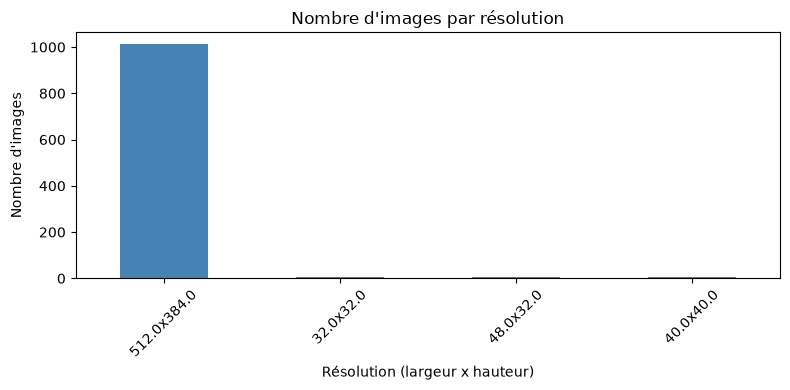

In [19]:
plt.figure(figsize=(8, 4))
compte_resolutions.index = compte_resolutions.index.map(lambda r: f"{r[0]}x{r[1]}")
compte_resolutions.plot(kind='bar', color='steelblue')
plt.ylabel("Nombre d'images")
plt.xlabel('Résolution (largeur x hauteur)')
plt.title('Nombre d\'images par résolution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2) Images sous la résolution minimale requise (64 × 64 pixels)

In [20]:
images_trop_petites = df_valides[(df_valides['largeur'] < 64) | (df_valides['hauteur'] < 64)][['nom', 'classe', 'largeur', 'hauteur']]
images_trop_petites

,nom,classe,largeur,hauteur
20,cardboard117.jpg,cardboard,48.0,32.0
77,cardboard22.jpg,cardboard,32.0,32.0
133,cardboard70.jpg,cardboard,40.0,40.0
171,glass100.jpg,glass,40.0,40.0
229,glass15.jpg,glass,48.0,32.0
268,glass21.jpg,glass,32.0,32.0
270,glass23.jpg,glass,32.0,32.0
383,metal121.jpg,metal,48.0,32.0
413,metal2.jpg,metal,32.0,32.0
421,metal26.jpg,metal,40.0,40.0


In [21]:
audit_stats["Images trop petites"] = len(images_trop_petites)
sauvegarder_audit()

,total d'images,Images corrompues,Images quasi vides,Images trop petites
0,1032,6,4,13


**Réponse.**
1) Le dataset contient **4 résolutions distinctes** : très majoritairement `512x384` (1013 images), et quelques images beaucoup plus petites en `32x32` (5), `40x40` (4) et `48x32` (4). La résolution minimale est donc **32×32** et la résolution maximale **512×384**, avec un rapport d'aire d'environ **192** entre les deux — un écart considérable qui justifie un redimensionnement homogène (Partie 9).
2) **13 images** ont une largeur ou une hauteur inférieure à 64 pixels (les mêmes 13 images en `32x32`, `40x40` et `48x32`) : elles ne respectent pas la contrainte minimale et devront être traitées avec attention lors du redimensionnement (le padding conservera leurs proportions mais leur contenu reste peu informatif une fois agrandi).

## Partie 5 – Détecter les différents canaux

### Nombre d'images par nombre de canaux (d'après le mode PIL)

In [22]:
df_valides['canaux'].value_counts().sort_index()

canaux
1.0       2
3.0    1006
4.0      18
Name: count, dtype: int64

In [23]:
audit_stats["Images RGBA"] = int((df_valides['mode'] == 'RGBA').sum())
sauvegarder_audit()

,total d'images,Images corrompues,Images quasi vides,Images trop petites,Images RGBA
0,1032,6,4,13,18


### Images visuellement en niveaux de gris malgré un mode RGB/RGBA

Le mode PIL ne suffit pas : une image peut être stockée en RGB tout en étant visuellement en niveaux de gris (R ≈ G ≈ B pour chaque pixel). On détecte ce cas en comparant les canaux entre eux.

In [24]:
SEUIL_ECART_CANAUX_GRIS = 2.0

def est_grayscale_visuel(chemin: Path, seuil: float = SEUIL_ECART_CANAUX_GRIS) -> bool:
    """Renvoie True si les canaux R, G, B sont quasiment identiques pixel a pixel
    (image visuellement en niveaux de gris, meme si stockee en RGB/RGBA)."""
    with Image.open(chemin) as img:
        img.load()
        arr = np.array(img.convert('RGB'), dtype=np.float64)
    r, g, b = arr[..., 0], arr[..., 1], arr[..., 2]
    ecart_max = max(np.abs(r - g).mean(), np.abs(r - b).mean(), np.abs(g - b).mean())
    return bool(ecart_max < seuil)

In [25]:
df_valides['grayscale_visuel'] = df_valides['chemin'].apply(lambda p: est_grayscale_visuel(Path(p)))
images_grayscale = df_valides[df_valides['grayscale_visuel']]
images_grayscale[['nom', 'classe', 'mode']]

,nom,classe,mode
45,cardboard13v.png,cardboard,RGBA
81,cardboard25g.png,cardboard,RGBA
93,cardboard35tg.png,cardboard,RGBA
109,cardboard4g.png,cardboard,RGBA
112,cardboard50rg.png,cardboard,RGBA
150,cardboard85g.png,cardboard,RGBA
167,image-blanche-512x384.jpg,cardboard,RGB
181,glass109g.png,glass,RGBA
191,glass117g.png,glass,RGBA
194,glass11g.png,glass,RGBA


In [26]:
audit_stats["Images grayscale"] = len(images_grayscale)
sauvegarder_audit()

,total d'images,Images corrompues,Images quasi vides,Images trop petites,Images RGBA,Images grayscale
0,1032,6,4,13,18,21


**Réponse.** Sur les 1026 images lisibles, on compte **1006 images à 3 canaux (RGB)**, **18 images à 4 canaux (RGBA)** et **2 images à 1 canal effectif (mode `P`, palette indexée)**. Parmi elles, **18 images sont en mode RGBA** (canal alpha) et **21 images sont visuellement en niveaux de gris** bien que stockées en RGB/RGBA (canaux R, G, B quasi identiques) : le dataset n'est donc homogène ni dans son nombre de canaux, ni dans son contenu colorimétrique réel. Ces différences seront corrigées en Partie 10 (uniformisation en RGB).

## Partie 6 – Détecter les doublons

### Fonction de hachage du contenu pixel d'une image

Deux fichiers différents (noms, voire formats/compressions différents) peuvent contenir exactement la même image. On hache donc le **contenu des pixels** (après conversion en RGB pour ignorer d'éventuelles différences de mode) plutôt que les octets bruts du fichier.

In [27]:
def hash_pixels(chemin: Path):
    """Hash MD5 du contenu pixel (RGB) d'une image, insensible au nom de fichier, au format
    et a la compression. Renvoie None si l'image est corrompue."""
    try:
        with Image.open(chemin) as img:
            img.load()
            arr = np.array(img.convert('RGB'))
        return hashlib.md5(arr.tobytes()).hexdigest()
    except Exception:
        return None

### Application : recherche des groupes d'images identiques

In [28]:
df_valides['hash_pixels'] = df_valides['chemin'].apply(lambda p: hash_pixels(Path(p)))
groupes_doublons = df_valides.groupby('hash_pixels').filter(lambda g: len(g) > 1)
groupes_doublons[['hash_pixels', 'classe', 'nom']].sort_values('hash_pixels')

,hash_pixels,classe,nom
980,020356755d7631716228a952bf3c3ead,plastic,plasticx199.jpg
869,020356755d7631716228a952bf3c3ead,plastic,plastic199.jpg
258,03b62f7033ed13e63138ebd048abc4ea,glass,glass176.jpg
817,03b62f7033ed13e63138ebd048abc4ea,plastic,plastic152.jpg
732,116e03527a54192f3693d884d259d23b,paper,paper77ty.jpg
731,116e03527a54192f3693d884d259d23b,paper,paper77.jpg
387,16e737d7e848620a6e96cc7e4f75dd37,metal,metal125.jpg
388,16e737d7e848620a6e96cc7e4f75dd37,metal,metal125po.jpg
168,22a0ea89c32ebdf57e195d9d0b8da9d6,cardboard,image-violet-512x384.gif
356,22a0ea89c32ebdf57e195d9d0b8da9d6,glass,image-violet-512x384.gif


In [29]:
nb_groupes = groupes_doublons['hash_pixels'].nunique()
nb_doublons_en_trop = len(groupes_doublons) - nb_groupes
print(f"Nombre de groupes de doublons : {nb_groupes}")
print(f"Nombre de fichiers concernes : {len(groupes_doublons)}")
print(f"Fichiers en trop (1 exemplaire garde par groupe) : {nb_doublons_en_trop}")

Nombre de groupes de doublons : 15
Nombre de fichiers concernes : 30
Fichiers en trop (1 exemplaire garde par groupe) : 15


In [30]:
audit_stats["Doublons"] = int(nb_doublons_en_trop)
sauvegarder_audit()

,total d'images,Images corrompues,Images quasi vides,Images trop petites,Images RGBA,Images grayscale,Doublons
0,1032,6,4,13,18,21,15


**Réponse.** On trouve **15 groupes de doublons** (30 fichiers concernés, soit **15 fichiers en trop**). La plupart sont des doublons intra-classe portant des noms différents (ex. `metal35.jpg` / `metal35rt.jpg`), mais **deux groupes sont des doublons inter-classes** : `glass176.jpg` == `plastic152.jpg` et `glass115.jpg` == `metal91.jpg`. Ces deux cas seront réexaminés en Partie 7 (une même image ne peut pas être à la fois dans `glass` et dans `plastic`/`metal` : l'une des deux copies est forcément mal classée).

## Partie 7 – Détecter les images mal classées

### Aperçu visuel aléatoire par classe

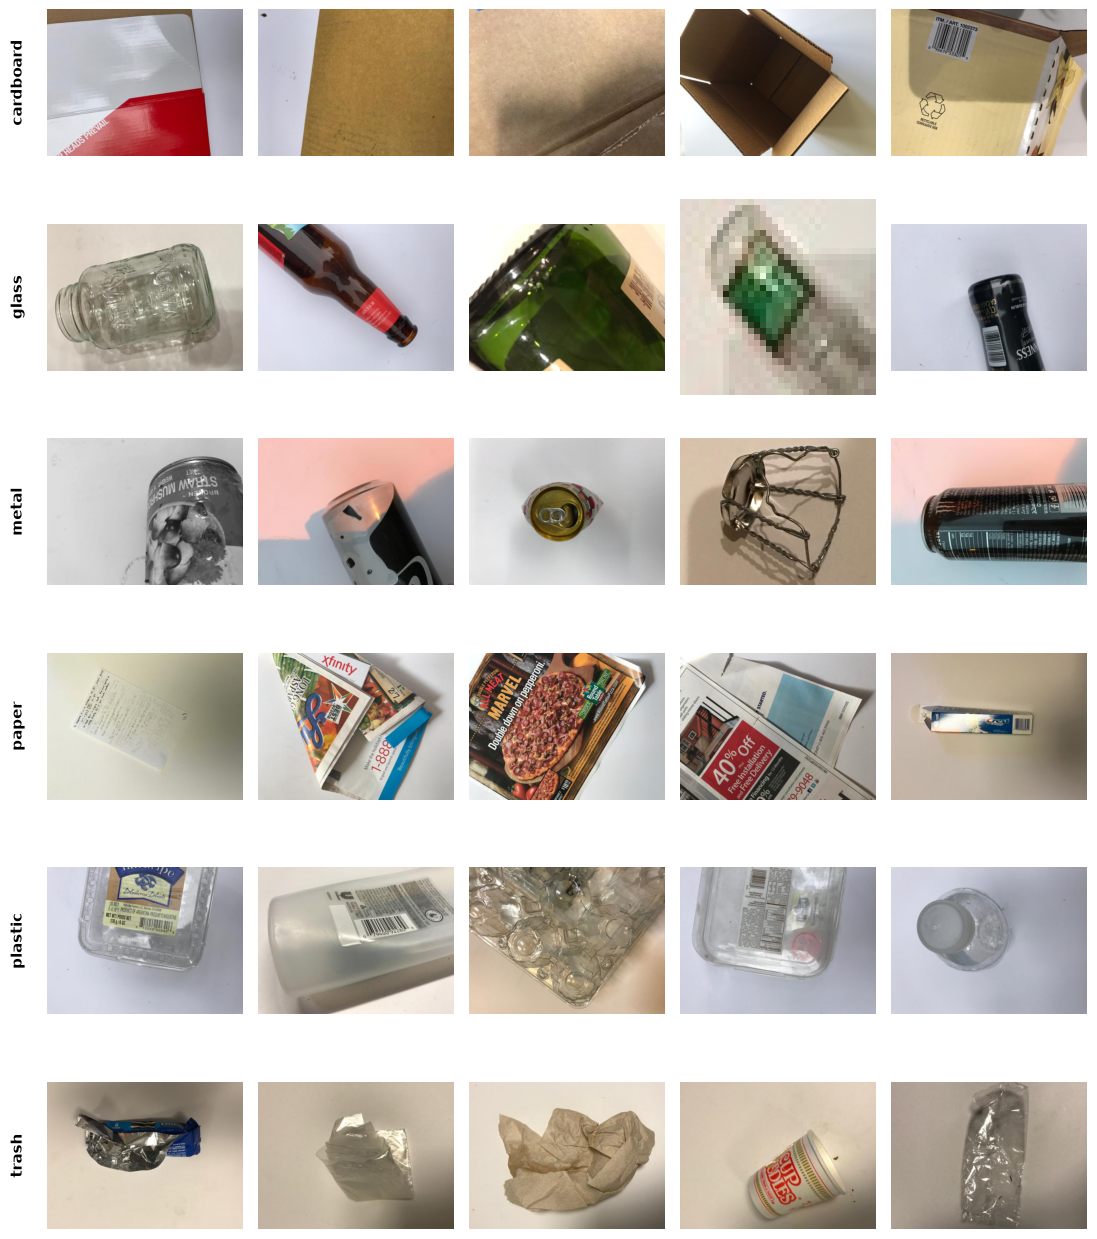

In [31]:
rng = np.random.default_rng(42)
n_par_classe = 5
fig, axes = plt.subplots(len(CLASSES), n_par_classe, figsize=(2.2 * n_par_classe, 2.2 * len(CLASSES)))
for i, classe in enumerate(CLASSES):
    sous_ens = df_valides[(df_valides['classe'] == classe) & (~df_valides['vide'])]
    echantillon = sous_ens.sample(n=n_par_classe, random_state=42)
    for j, (_, ligne) in enumerate(echantillon.iterrows()):
        ax = axes[i, j]
        with Image.open(ligne['chemin']) as img:
            ax.imshow(img.convert('RGB'))
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(classe)
            ax.text(-0.15, 0.5, classe, transform=ax.transAxes, rotation=90, va='center', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### Cas suspects issus de la Partie 6 (doublons inter-classes) et des noms de fichiers atypiques

La Partie 6 a révélé deux doublons **inter-classes** : `glass176.jpg` == `plastic152.jpg` et `glass115.jpg` == `metal91.jpg`. Une même photo ne peut appartenir qu'à une seule vraie classe : on l'inspecte visuellement pour trancher. On vérifie aussi `plasticx199fd.jpg`, un nom de fichier atypique (suffixe différent de son quasi-doublon `plasticx199.jpg`).

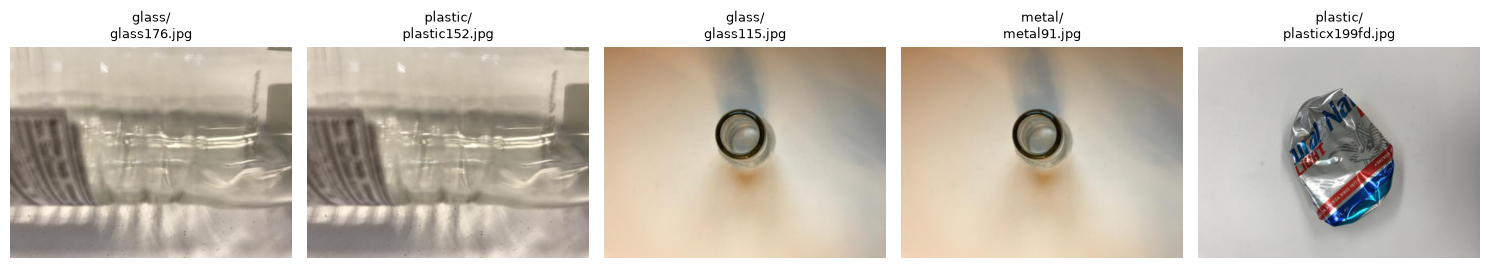

In [32]:
cas_a_verifier = [
    ('glass', 'glass176.jpg'), ('plastic', 'plastic152.jpg'),
    ('glass', 'glass115.jpg'), ('metal', 'metal91.jpg'),
    ('plastic', 'plasticx199fd.jpg'),
]
fig, axes = plt.subplots(1, len(cas_a_verifier), figsize=(3 * len(cas_a_verifier), 3))
for ax, (classe, nom) in zip(axes, cas_a_verifier):
    with Image.open(RAW_DIR / classe / nom) as img:
        ax.imshow(img.convert('RGB'))
    ax.set_title(f"{classe}/\n{nom}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

**Réponse.** Le contrôle visuel révèle **3 images mal classées**, toutes dans `data/raw/` :
- `plastic152.jpg` (dossier `plastic`) montre en réalité une **bouteille en verre** (identique pixel pour pixel à `glass176.jpg`) → classe réelle **glass**.
- `metal91.jpg` (dossier `metal`) montre en réalité un **goulot de bouteille en verre** vu de dessus (identique à `glass115.jpg`) → classe réelle **glass**.
- `plasticx199fd.jpg` (dossier `plastic`) montre en réalité une **canette en aluminium écrasée** → classe réelle **metal**.

Ces corrections de classe seront appliquées lors de la construction de `data/cleaned/` (le dossier `data/raw/` original n'est jamais modifié).

In [33]:
images_mal_classees = pd.DataFrame([
    {'nom': 'plastic152.jpg', 'classe_actuelle': 'plastic', 'classe_reelle': 'glass'},
    {'nom': 'metal91.jpg', 'classe_actuelle': 'metal', 'classe_reelle': 'glass'},
    {'nom': 'plasticx199fd.jpg', 'classe_actuelle': 'plastic', 'classe_reelle': 'metal'},
])
images_mal_classees

,nom,classe_actuelle,classe_reelle
0,plastic152.jpg,plastic,glass
1,metal91.jpg,metal,glass
2,plasticx199fd.jpg,plastic,metal


In [34]:
audit_stats["images mal classees"] = len(images_mal_classees)
sauvegarder_audit()

,total d'images,Images corrompues,Images quasi vides,Images trop petites,Images RGBA,Images grayscale,Doublons,images mal classees
0,1032,6,4,13,18,21,15,3


## Partie 8 – Analyser le déséquilibre des classes

### Nombre d'images par classe

In [35]:
images_par_classe = df_audit['classe'].value_counts()
images_par_classe

classe
paper        252
plastic      224
glass        188
cardboard    169
metal        149
trash         50
Name: count, dtype: int64

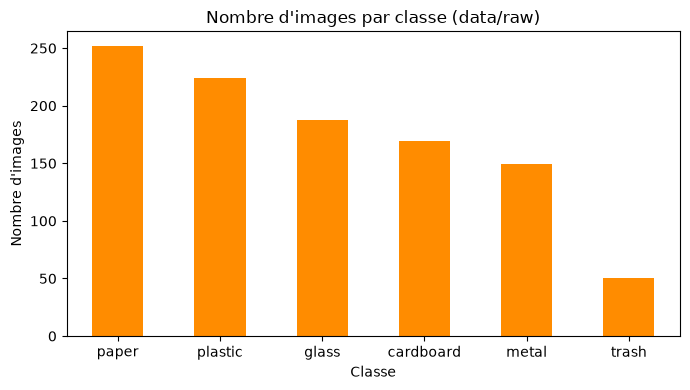

In [36]:
plt.figure(figsize=(7, 4))
images_par_classe.plot(kind='bar', color='darkorange')
plt.ylabel("Nombre d'images")
plt.xlabel('Classe')
plt.title("Nombre d'images par classe (data/raw)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
ratio_desequilibre = images_par_classe.max() / images_par_classe.min()
print(f"Classe majoritaire : {images_par_classe.idxmax()} ({images_par_classe.max()} images)")
print(f"Classe minoritaire : {images_par_classe.idxmin()} ({images_par_classe.min()} images)")
print(f"Ratio de desequilibre : {ratio_desequilibre:.2f}")

Classe majoritaire : paper (252 images)
Classe minoritaire : trash (50 images)
Ratio de desequilibre : 5.04


### Bilan complet de l'audit (`reports/audit_images.csv`)

Toutes les statistiques demandées par l'énoncé sont désormais réunies dans le fichier d'audit.

In [38]:
sauvegarder_audit()

,total d'images,Images corrompues,Images quasi vides,Images trop petites,Images RGBA,Images grayscale,Doublons,images mal classees
0,1032,6,4,13,18,21,15,3


**Réponse.** Le dataset est **déséquilibré** : `paper` est la classe majoritaire avec **252 images**, tandis que `trash` est très minoritaire avec seulement **50 images**, soit un ratio de déséquilibre d'environ **5**. Les autres classes se situent entre les deux (`cardboard` : 169, `glass` : 188, `metal` : 149, `plastic` : 224). Ce déséquilibre justifiera l'application d'une data augmentation ciblée sur `trash` en Partie 13.

## Construction de `data/cleaned/` : sélection des images à nettoyer

Avant de redimensionner/normaliser, on établit la liste définitive des images à copier dans `data/cleaned/`, en s'appuyant sur tout l'audit réalisé en Parties 1 à 7 :
- les **6 images corrompues** sont exclues ;
- les **4 images quasi vides** (noires/blanches) sont exclues ;
- pour chaque **groupe de doublons**, un seul exemplaire (le premier par ordre alphabétique) est conservé ;
- les **3 images mal classées** sont réaffectées à leur classe réelle (`plastic152.jpg` → glass, `metal91.jpg` → glass, `plasticx199fd.jpg` → metal).

Le dossier `data/raw/` original n'est jamais modifié (lecture seule).

In [39]:
corrections_classe = {
    'plastic152.jpg': 'glass',
    'metal91.jpg': 'glass',
    'plasticx199fd.jpg': 'metal',
}

candidats = df_valides[~df_valides['vide']].copy()
candidats['classe_finale'] = candidats['nom'].map(corrections_classe).fillna(candidats['classe'])

def marquer_representant(groupe):
    groupe = groupe.sort_values('nom')
    marque = pd.Series(False, index=groupe.index)
    marque.iloc[0] = True
    return marque

candidats['a_conserver'] = candidats.groupby('hash_pixels', group_keys=False).apply(marquer_representant)
df_a_nettoyer = candidats[candidats['a_conserver']].copy()
print(f"Images candidates avant dedoublonnage : {len(candidats)}")
print(f"Images retenues pour data/cleaned : {len(df_a_nettoyer)}")
df_a_nettoyer['classe_finale'].value_counts()

Images candidates avant dedoublonnage : 1022
Images retenues pour data/cleaned : 1009


classe_finale
paper        248
plastic      217
glass        185
cardboard    167
metal        143
trash         49
Name: count, dtype: int64

## Partie 9 – Redimensionnement

Redimensionner toutes les images à 224 × 224.

*NB : redimensionnement avec conservation des proportions et ajout éventuel de padding.*

### Fonction de redimensionnement avec conservation des proportions (letterbox padding)

In [40]:
TAILLE_CIBLE = 224

def redimensionner_avec_padding(img: Image.Image, taille: int = TAILLE_CIBLE) -> Image.Image:
    """Redimensionne une image a taille x taille en conservant son ratio largeur/hauteur,
    et complete l'espace restant par un padding noir (letterboxing) centre."""
    ratio = min(taille / img.width, taille / img.height)
    nouvelle_taille = (max(1, round(img.width * ratio)), max(1, round(img.height * ratio)))
    img_redim = img.resize(nouvelle_taille, Image.LANCZOS)
    fond = Image.new(img.mode, (taille, taille), 0)
    decalage = ((taille - nouvelle_taille[0]) // 2, (taille - nouvelle_taille[1]) // 2)
    fond.paste(img_redim, decalage)
    return fond

### Application : redimensionnement et écriture dans `data/cleaned/`

In [41]:
for classe in CLASSES:
    (CLEANED_DIR / classe).mkdir(parents=True, exist_ok=True)

for _, ligne in df_a_nettoyer.iterrows():
    with Image.open(ligne['chemin']) as img:
        img.load()
        img_redim = redimensionner_avec_padding(img)
    extension = '.png' if img_redim.mode in ('RGBA', 'P') else '.jpg'
    nom_sortie = Path(ligne['nom']).stem + extension
    img_redim.save(CLEANED_DIR / ligne['classe_finale'] / nom_sortie)

print('Redimensionnement termine.')

Redimensionnement termine.


In [42]:
tailles_verif = {p.stem: Image.open(p).size for p in list((CLEANED_DIR / CLASSES[0]).iterdir())[:3]}
tailles_verif

{'cardboard1': (224, 224),
 'cardboard10': (224, 224),
 'cardboard100': (224, 224)}

## Partie 10 – Uniformisation des canaux

Convertir toutes les images de `data/cleaned/` en RGB. Avant conversion, le redimensionnement de la Partie 9 a préservé le mode d'origine de chaque image (RGB, RGBA ou P) : le dataset `cleaned` n'est donc pas encore homogène en nombre de canaux.

In [43]:
from collections import Counter

compte_modes_avant = Counter()
for chemin in CLEANED_DIR.rglob('*'):
    if chemin.is_file():
        with Image.open(chemin) as img:
            compte_modes_avant[img.mode] += 1
print('Modes avant conversion :', dict(compte_modes_avant))

Modes avant conversion : {'RGB': 992, 'RGBA': 16, 'P': 1}


In [44]:
nb_convertis = 0
for chemin in CLEANED_DIR.rglob('*'):
    if not chemin.is_file():
        continue
    with Image.open(chemin) as img:
        if img.mode != 'RGB':
            img_rgb = img.convert('RGB')
            img_rgb.save(chemin)
            nb_convertis += 1
print(f"{nb_convertis} images converties en RGB.")

17 images converties en RGB.


In [45]:
compte_modes_apres = Counter()
for chemin in CLEANED_DIR.rglob('*'):
    if chemin.is_file():
        with Image.open(chemin) as img:
            compte_modes_apres[img.mode] += 1
print('Modes apres conversion :', dict(compte_modes_apres))

Modes apres conversion : {'RGB': 1009}


**Réponse.** 17 images n'étaient pas en RGB (16 en RGBA, 1 en mode `P` palette) : elles ont été converties. Après conversion, les **1009 images** de `data/cleaned/` sont toutes en mode **RGB (3 canaux)**, ce qui est indispensable pour les entraîner ensemble dans un même modèle (une couche d'entrée de CNN attend un nombre de canaux fixe).

## Partie 11 – Mise à l'échelle des pixels

Normaliser les valeurs des pixels de toutes les images.

Les fichiers de `data/cleaned/` restent stockés en JPEG/PNG classiques (entiers 8 bits, 0-255) : c'est le format lisible et partageable du jeu de données nettoyé. La normalisation des pixels est une étape du **pipeline de chargement** pour l'entraînement (comme le ferait `tf.keras.utils.image_dataset_from_directory` + une couche `Rescaling`), pas une transformation qu'on réécrit sur disque. On l'implémente donc comme une fonction de chargement.

In [46]:
def charger_image_normalisee(chemin: Path) -> np.ndarray:
    """Charge une image et renvoie un tableau float32 avec des valeurs de pixels dans [0, 1]."""
    with Image.open(chemin) as img:
        arr = np.array(img.convert('RGB'), dtype=np.float32)
    return arr / 255.0

### Vérification sur un échantillon

In [47]:
exemple_chemin = next((CLEANED_DIR / CLASSES[0]).iterdir())
with Image.open(exemple_chemin) as img:
    arr_brut = np.array(img.convert('RGB'))
arr_normalise = charger_image_normalisee(exemple_chemin)
print(f"Avant normalisation : dtype={arr_brut.dtype}, min={arr_brut.min()}, max={arr_brut.max()}")
print(f"Apres normalisation : dtype={arr_normalise.dtype}, min={arr_normalise.min():.3f}, max={arr_normalise.max():.3f}")

Avant normalisation : dtype=uint8, min=0, max=255
Apres normalisation : dtype=float32, min=0.000, max=1.000


**Réponse.** Chaque image est chargée puis convertie d'un tableau `uint8` (0 à 255) en tableau `float32` avec des valeurs dans **[0, 1]** (division par 255). Cette normalisation est appliquée **à la volée au chargement**, pas en écrasant les fichiers de `data/cleaned/` : cela garde le dataset nettoyé lisible/partageable (images 8 bits classiques) tout en fournissant à l'entraînement des pixels à l'échelle attendue par les réseaux de neurones (convergence plus rapide et plus stable que des pixels 0-255).

## Partie 12 – Découpage Train/Validation/Test

On découpe `data/cleaned/` en **train (70 %)**, **validation (15 %)** et **test (15 %)**, de façon **stratifiée par classe** (pour conserver dans chaque sous-ensemble le même déséquilibre relatif que le dataset complet) et reproductible (`random_state` fixé).

In [48]:
from sklearn.model_selection import train_test_split

fichiers_cleaned = [(p, p.parent.name) for p in CLEANED_DIR.rglob('*') if p.is_file()]
df_cleaned = pd.DataFrame(fichiers_cleaned, columns=['chemin', 'classe'])

train_files, temp_files = train_test_split(
    df_cleaned, test_size=0.30, stratify=df_cleaned['classe'], random_state=42)
val_files, test_files = train_test_split(
    temp_files, test_size=0.50, stratify=temp_files['classe'], random_state=42)

print(f"Train : {len(train_files)} | Validation : {len(val_files)} | Test : {len(test_files)}")

Train : 706 | Validation : 151 | Test : 152


### Écriture des sous-ensembles dans `data/splits/`

In [49]:
SPLITS_DIR = Path('../data/splits')
splits = {'train': train_files, 'val': val_files, 'test': test_files}

for nom_split, sous_ens in splits.items():
    for classe in CLASSES:
        (SPLITS_DIR / nom_split / classe).mkdir(parents=True, exist_ok=True)
    for chemin, classe in zip(sous_ens['chemin'], sous_ens['classe']):
        shutil.copy2(chemin, SPLITS_DIR / nom_split / classe / chemin.name)

print('Copie terminee.')
for nom_split in splits:
    total = sum(len(list((SPLITS_DIR / nom_split / c).iterdir())) for c in CLASSES)
    print(f"{nom_split} : {total} images")

Copie terminee.
train : 808 images
val : 151 images
test : 152 images


In [50]:
repartition = pd.DataFrame({
    nom_split: sous_ens['classe'].value_counts() for nom_split, sous_ens in splits.items()
}).fillna(0).astype(int)
repartition

,train,val,test
classe,,,
paper,174,37,37
plastic,152,32,33
glass,129,28,28
cardboard,117,25,25
metal,100,21,22
trash,34,8,7


**Réponse.** Le dataset nettoyé (1009 images) est découpé en **train (706 images, 70 %)**, **validation (151 images, 15 %)** et **test (152 images, 15 %)**, de façon stratifiée : chaque classe conserve approximativement les mêmes proportions dans les trois sous-ensembles, ce qui évite qu'un split ne soit accidentellement privé d'une classe minoritaire comme `trash`.

## Partie 13 – Data Augmentation

### 1) Augmentation de la classe minoritaire (`trash`) avec Keras

La classe `trash` est la plus minoritaire (34 images dans `data/splits/train/`, contre 100 à 174 pour les autres classes). On construit un pipeline d'augmentation avec des couches Keras : rotation légère, retournement horizontal, zoom, translation, variation de luminosité, de contraste et de teinte (couleur).

In [51]:
import keras
from keras import layers

keras.utils.set_random_seed(42)  # reproductibilite des transformations aleatoires

pipeline_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.04),            # rotation legere (~ +/-14 degres)
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
    layers.RandomHue(0.03),                  # legere variation de couleur
], name='augmentation_trash')

### Application : génération de versions augmentées pour `train/trash`

On augmente uniquement le sous-ensemble **train** (jamais validation/test) de la classe minoritaire, en générant plusieurs versions augmentées de chaque image originale.

In [52]:
NB_AUGMENTATIONS_PAR_IMAGE = 3
tf_random_seed = 42

dossier_train_trash = SPLITS_DIR / 'train' / 'trash'

# on repart des images originales (sans suffixe _aug) pour que la cellule soit re-executable
images_originales = [p for p in dossier_train_trash.iterdir() if '_aug' not in p.stem]
for p in dossier_train_trash.iterdir():
    if '_aug' in p.stem:
        p.unlink()

compteur = 0
for chemin in images_originales:
    with Image.open(chemin) as img:
        arr = np.array(img.convert('RGB'), dtype=np.float32)[None, ...]  # batch de 1
    for i in range(NB_AUGMENTATIONS_PAR_IMAGE):
        arr_aug = pipeline_augmentation(arr, training=True).numpy()[0]
        arr_aug = np.clip(arr_aug, 0, 255).astype(np.uint8)
        Image.fromarray(arr_aug).save(dossier_train_trash / f"{chemin.stem}_aug{i+1}.jpg")
        compteur += 1

print(f"{len(images_originales)} images originales -> {compteur} images augmentees generees.")
print(f"Nouvelle taille de train/trash : {len(list(dossier_train_trash.iterdir()))} images.")

34 images originales -> 102 images augmentees generees.
Nouvelle taille de train/trash : 136 images.


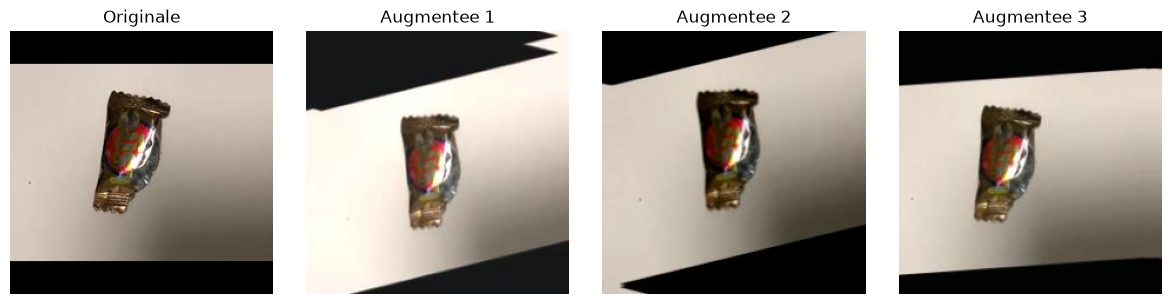

In [53]:
exemple_stem = images_originales[0].stem
fig, axes = plt.subplots(1, NB_AUGMENTATIONS_PAR_IMAGE + 1, figsize=(3 * (NB_AUGMENTATIONS_PAR_IMAGE + 1), 3))
with Image.open(dossier_train_trash / f"{exemple_stem}.jpg") as img:
    axes[0].imshow(img)
axes[0].set_title('Originale')
axes[0].axis('off')
for i in range(NB_AUGMENTATIONS_PAR_IMAGE):
    with Image.open(dossier_train_trash / f"{exemple_stem}_aug{i+1}.jpg") as img:
        axes[i + 1].imshow(img)
    axes[i + 1].set_title(f'Augmentee {i+1}')
    axes[i + 1].axis('off')
plt.tight_layout()
plt.show()

### 2) Pourquoi éviter de faire la data augmentation avant le découpage du dataset ?

**Réponse.** Si l'augmentation est faite **avant** le split train/validation/test, plusieurs versions augmentées d'une même image originale peuvent se retrouver dans des sous-ensembles différents (par exemple l'original en `train` et une version augmentée du même cliché en `test`). Le modèle aurait alors déjà "vu" une image quasi identique pendant l'entraînement avant de l'évaluer : c'est une **fuite de données (data leakage)**. Les performances mesurées sur validation/test seraient artificiellement optimistes et ne refléteraient pas la capacité réelle du modèle à généraliser sur des images totalement inédites.

C'est pourquoi on augmente **après** le split, et uniquement le sous-ensemble **train** : `validation` et `test` doivent rester composés d'images strictement originales et jamais vues sous une autre forme pendant l'entraînement, pour donner une estimation honnête de la performance du modèle.